In [87]:
from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pylab as plt

In [4]:
page_time = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/web_page_data.csv")
page_time.Time *= 100
page_time

,Page,Time
0,Page A,21.0
1,Page B,253.0
2,Page A,35.0
3,Page B,71.0
4,Page A,67.0
5,Page B,85.0
6,Page A,211.0
7,Page B,246.0
8,Page A,132.0
9,Page B,149.0


In [5]:
groupA = page_time[page_time.Page == "Page A"].Time.mean()
groupB = page_time[page_time.Page == "Page B"].Time.mean()

In [6]:
groupB - groupA

np.float64(35.66666666666667)

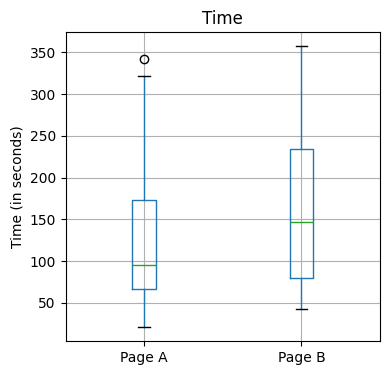

In [7]:
ax = page_time.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()


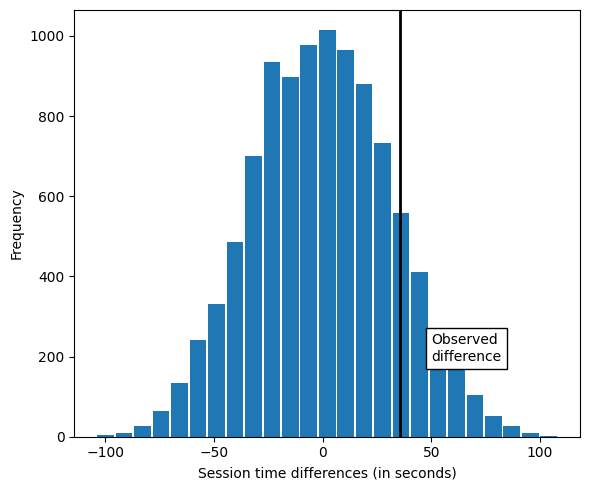

In [8]:
def permutation_func(pd_time, rows_a, rows_b) -> float:
    n = rows_a + rows_b
    idx_b = set(random.sample(range(n), rows_b))
    idx_a = set(range(n)) - idx_b
    return pd_time.loc[list(idx_b)].mean() - pd_time.loc[list(idx_a)].mean()
    
rows_a = page_time[page_time.Page == 'Page A'].shape[0]
rows_b = page_time[page_time.Page == 'Page B'].shape[0]

# permutation_test = pd.DataFrame({"difference": []})
# for i in range(10000):
#     permutation_test.loc[len(permutation_test)] = permutation_func(page_time.Time, rows_a, rows_b)
# permutation_test.plot.hist(bins=25)


perm_diffs = [permutation_func(page_time.Time, rows_a, rows_b) for _ in range(10000)]

fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(perm_diffs, bins=25, rwidth=0.9)
ax.axvline(x=groupB - groupA, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
count_data = pd.DataFrame(perm_diffs > groupB - groupA).value_counts()
count_data
print(count_data.iloc[1]/(count_data.iloc[0]+count_data.iloc[1]))
print(np.mean(perm_diffs > groupB - groupA))

0.1312
0.1312


observed difference: 0.03675791182059275
-0.004497620002510477


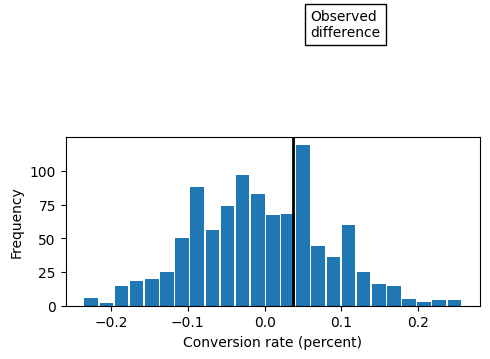

In [10]:
observed_diff = 100 * (200 / 23739 - 182 / 22588)
print(f"observed difference: {observed_diff}")
conversion = [0] * 45945 + [1] * 382
conversion = pd.Series(conversion)
permutation_diff = [100 * permutation_func(conversion, 23739, 22588) for _ in range(1000)]

# pd.Series(permutation_diff).plot.hist(bins=25)
print(np.mean(permutation_diff))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(permutation_diff, bins=25, rwidth=0.9)
ax.axvline(x=observed_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [11]:
# P-value

print(f"p-value from permutation test: {np.mean([diff > observed_diff for diff in permutation_diff])}")

survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'p-value for single sided test: {p_value / 2:.4f}')


p-value from permutation test: 0.331
p-value for single sided test: 0.3498


In [12]:
res = stats.ttest_ind(page_time[page_time.Page == 'Page A'].Time,
page_time[page_time.Page == 'Page B'].Time,
equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


In [27]:
data = {
    "Page 1": [164, 172, 177, 156, 195],
    "Page 2": [178, 191, 182, 185, 177],
    "Page 3": [175, 193, 171, 163, 176],
    "Page 4": [155, 166, 164, 170, 168]
}

four_sessions = pd.DataFrame(data)
four_sessions.loc["average"] = four_sessions.mean()
four_sessions.loc["grand_average"] = four_sessions.iloc[0:5,0:4].mean().mean()
four_sessions

,Page 1,Page 2,Page 3,Page 4
0,164.0,178.0,175.0,155.0
1,172.0,191.0,193.0,166.0
2,177.0,182.0,171.0,164.0
3,156.0,185.0,163.0,170.0
4,195.0,177.0,176.0,168.0
average,172.8,182.6,175.6,164.6
grand_average,173.9,173.9,173.9,173.9


In [ ]:
four_sessions1 = pd.read_csv("https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/refs/heads/master/data/four_sessions.csv")

observed_variance = four_sessions1.groupby('Page').mean().var().iloc[0]

print('Observed means:', four_sessions1.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)

def perm_test(df):
    df = df.copy()
    df["Time"] = np.random.permutation(df.Time.values)
    return df.groupby('Page').mean().var().iloc[0]

print(perm_test(four_sessions1))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
43.32000000000002


Pr(Prob) = 0.07466666666666667


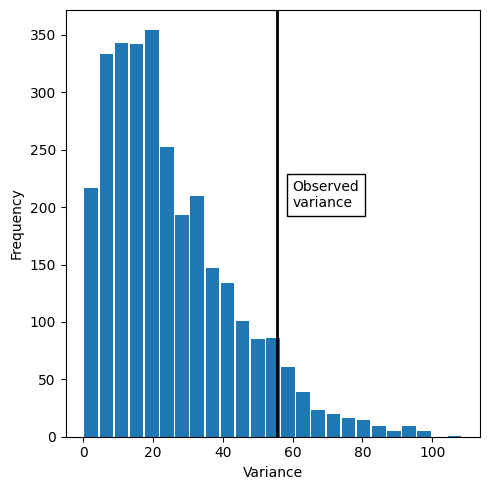

In [86]:
perm_variance = [perm_test(four_sessions1) for _ in range(3000)]
perm_variance

print(f"Pr(Prob) = {np.mean([var > observed_variance for var in perm_variance])}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=25, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
model1 = smf.ols("Time ~ Page", data=four_sessions1).fit()
sm.stats.anova_lm(model1)

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN
